In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

In [70]:
def wrangle(filepath):
    #read dataset
    df= pd.read_csv(filepath)

    #change Total charges str into the numpy array 
    if df['TotalCharges'].dtype=='str':
        df['TotalCharges'].str.strip()

        #convert empty set into NaN
        df['TotalCharges'].replace("", np.nan, inplace= True)
        df['TotalCharges']= pd.to_numeric(df['TotalCharges'], errors= 'coerce')


    return df

In [71]:
df= wrangle("/Users/Admin/Me only/Customer churn/src/data/Telco-Customer-Churn.csv")


/var/folders/6g/8yh8tlw52pq_wd00c_6f4r4w0000gn/T/ipykernel_14902/661201866.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].replace("", np.nan, inplace= True)


In [72]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [73]:
df.isnull().sum()



customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [74]:
print("Shape:" ,df.shape)

Shape: (7043, 21)


In [75]:
print(df.info())
print("Print any missing value")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [76]:
df['TotalCharges'].replace("", np.nan, inplace= True)

df['TotalCharges']= pd.to_numeric(df['TotalCharges'], errors= 'coerce')

/var/folders/6g/8yh8tlw52pq_wd00c_6f4r4w0000gn/T/ipykernel_14902/4263471114.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].replace("", np.nan, inplace= True)


# Target churn analysis

In [77]:
churn_count= df['Churn'].value_counts()
churn_rate= churn_count['Yes']/churn_count.sum()
imbalance_ratio= churn_count["No"]/churn_count["Yes"]

print('Churn counts:\n', churn_count)
print('\nChurn rate: {:.2%}'.format(churn_rate))
print('Imbalance ratio (No:Yes) = {:.2f}:1'.format(imbalance_ratio))

Churn counts:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54%
Imbalance ratio (No:Yes) = 2.77:1


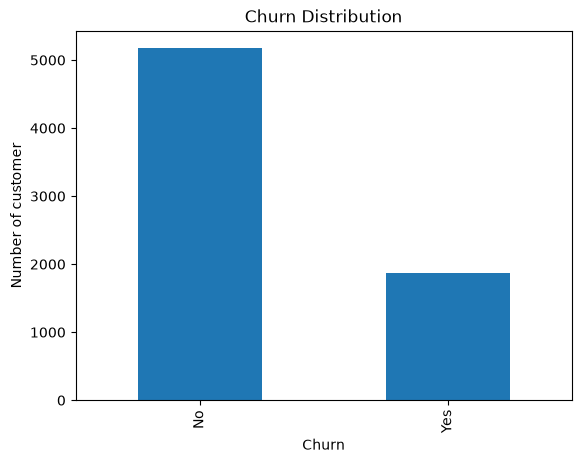

In [78]:
churn_count.plot(kind='bar')

plt.title("Churn Distribution")
plt.ylabel("Number of customer")
plt.show()

In [79]:
#Feature Categorization

DEMOGRAPHIC = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
ACCOUNT = ['tenure', 'Contract', 'PaperlessBilling', 'PaymentMethod']
SERVICES = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
FINANCIAL = ['MonthlyCharges', 'TotalCharges']

print('Demographic features:', DEMOGRAPHIC)
print('Account features:', ACCOUNT)
print('Service features:', SERVICES)
print('Financial features:', FINANCIAL)

Demographic features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
Account features: ['tenure', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Service features: ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
Financial features: ['MonthlyCharges', 'TotalCharges']


Text(0, 0.5, 'number of customer')

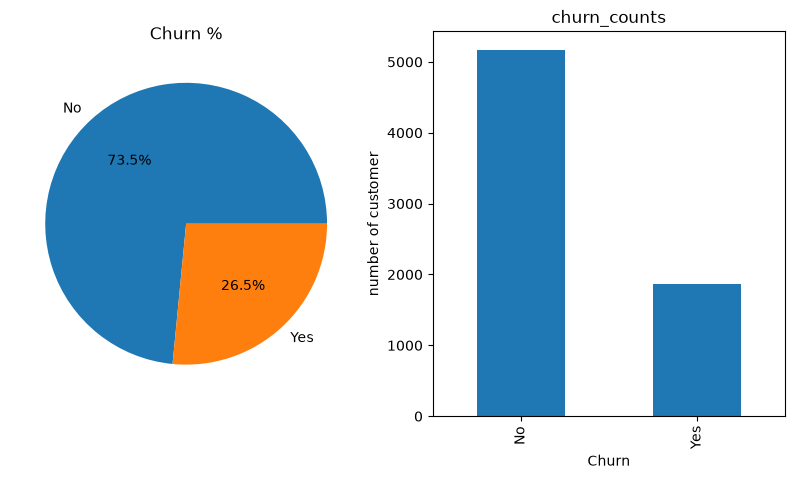

In [80]:
fig, axes= plt.subplots(1,2 ,figsize=(10,5))
churn_count.plot(kind='bar', title= "churn_counts")
churn_count.plot(kind='pie',autopct='%1.1f%%', ax=axes[0], title="Churn %")

axes[1].set_ylabel("number of customer")

In [81]:
contract_churn= df.groupby(df['Contract'])['Churn'].value_counts(normalize= True).unstack().fillna(0)

print("Contract churn proportion:")
print(contract_churn)

Contract churn proportion:
Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


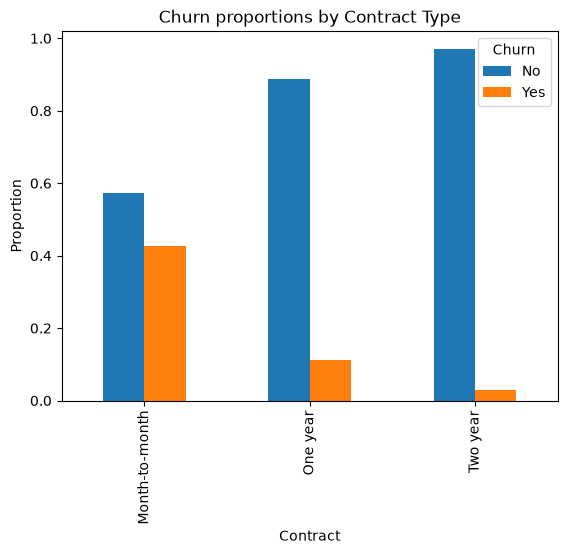

In [82]:
contract_churn.plot(kind= 'bar')
plt.title('Churn proportions by Contract Type')
plt.ylabel('Proportion');

* It is found that who has month-to-month contract has high number of churn rate, annualy is low and two year contract is very low.


# For Payment Method.

In [83]:
Payment_churn= df.groupby(df['PaymentMethod'])['Churn'].value_counts(normalize= True).unstack()

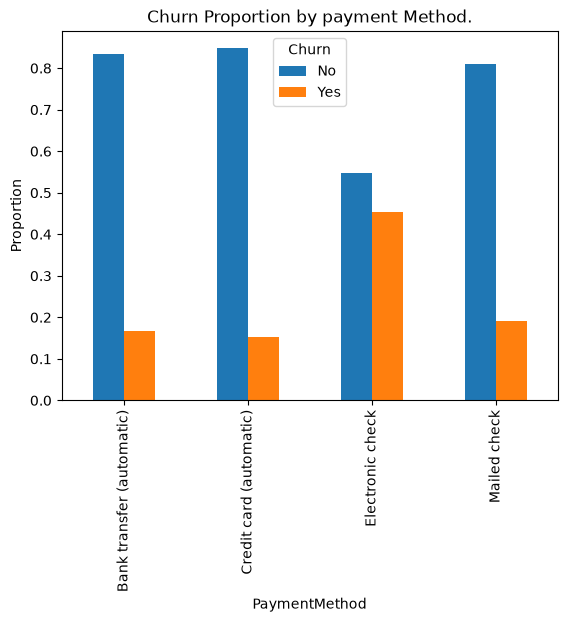

In [84]:
Payment_churn.plot(kind='bar', stacked= False   )
plt.title("Churn Proportion by payment Method.")
plt.ylabel("Proportion");

# For Internet service 

In [85]:
internet_service_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack().fillna(0)
print('\nInternet Service churn proportions:')
print(internet_service_churn)


Internet Service churn proportions:
Churn                  No       Yes
InternetService                    
DSL              0.810409  0.189591
Fiber optic      0.581072  0.418928
No               0.925950  0.074050


Text(0, 0.5, 'Proportion')

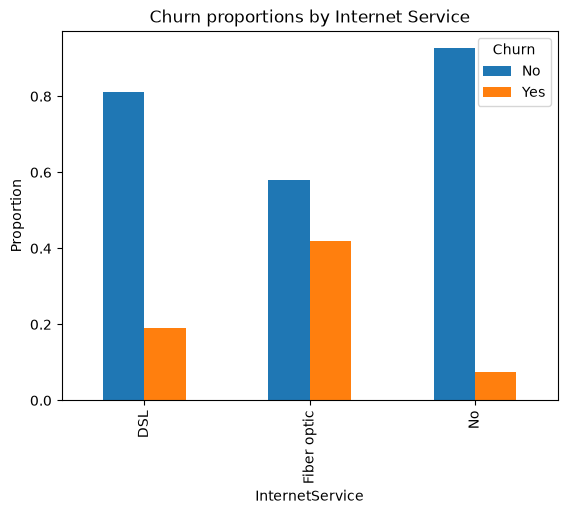

In [86]:
internet_service_churn.plot(kind='bar', stacked= False)
plt.title('Churn proportions by Internet Service')
plt.ylabel('Proportion')

# For Senior Citizens

In [87]:
churn_by_seniority= df.groupby(df['SeniorCitizen'])['Churn'].value_counts(normalize= True).unstack().fillna(0)
print("Churn by SeniorCitizen")
print(churn_by_seniority)

Churn by SeniorCitizen
Churn                No       Yes
SeniorCitizen                    
0              0.763938  0.236062
1              0.583187  0.416813


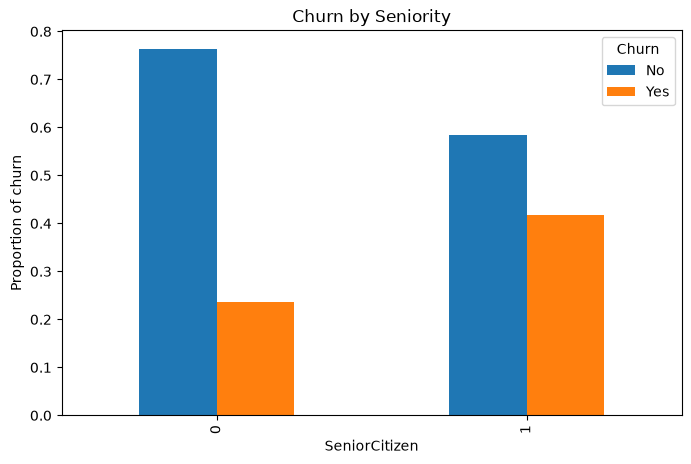

In [88]:
fig, axes= plt.subplots(1,1,figsize=(8,5))
churn_by_seniority.plot(kind= 'bar', ax= axes)
plt.title("Churn by Seniority")
plt.ylabel("Proportion of churn");



In [89]:
churn_by_partner= df.groupby(df['Partner'])['Churn'].value_counts(normalize= True).unstack()

Text(0, 0.5, 'Proportion')

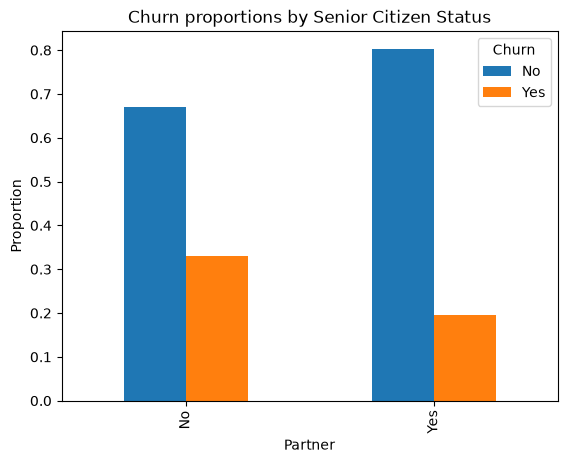

In [90]:
churn_by_partner.plot(kind='bar')
plt.title('Churn proportions by Senior Citizen Status')
plt.ylabel('Proportion')

In [91]:
churn_by_dependent= df.groupby(df['Dependents'])['Churn'].value_counts(normalize= True).unstack()

<Axes: xlabel='Dependents'>

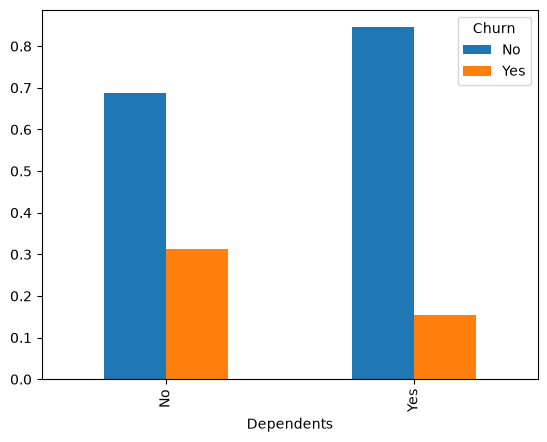

In [92]:
churn_by_dependent.plot(kind=  'bar')

In [93]:
online_security_churn = df.groupby('OnlineSecurity')['Churn'].value_counts(normalize=True).unstack().fillna(0)
print('\nOnline Security churn proportions:')
print(online_security_churn)


Online Security churn proportions:
Churn                      No       Yes
OnlineSecurity                         
No                   0.582333  0.417667
No internet service  0.925950  0.074050
Yes                  0.853888  0.146112


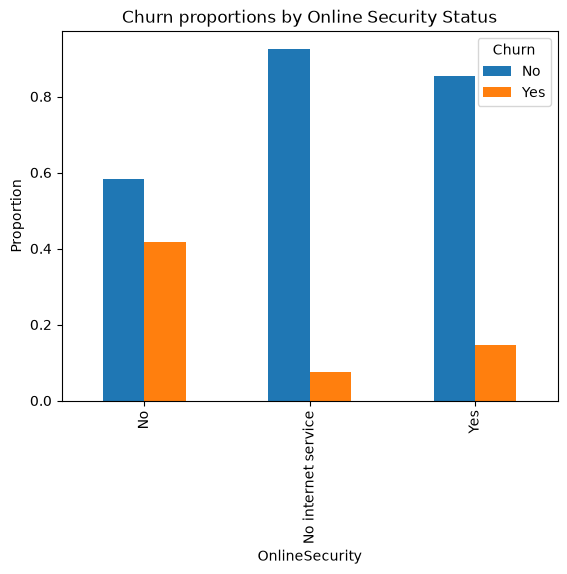

In [94]:
online_security_churn.plot(kind='bar')
plt.title('Churn proportions by Online Security Status')
plt.ylabel('Proportion')
plt.show()

# Advanced Univariate analysis.
* numerical Features: skew, distribution, outliers(IQR, Z-score.)
* Categorical Features: Frequency and relationship with churn.
* Feature Engineering

In [95]:
# df.describe().iloc[:, 1:]
num_cols= ['tenure', 'MonthlyCharges', 'TotalCharges']

for i in num_cols:
    display(df[i].describe())
    

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

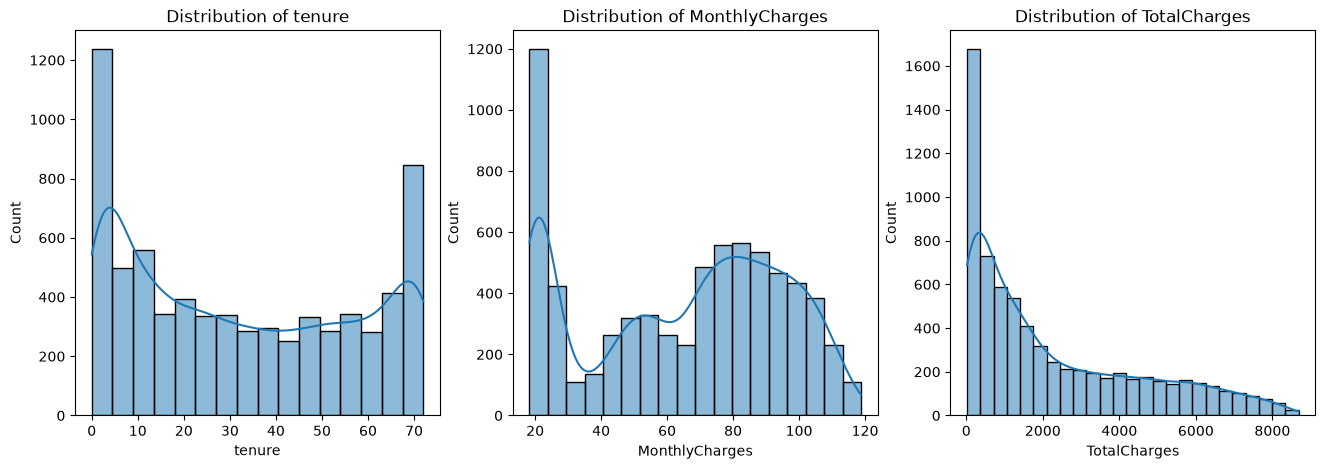

In [96]:
fig, axes= plt.subplots(1,3, figsize=(16,5))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde= True, ax= axes[i])
    axes[i].set_title(f"Distribution of {col}")

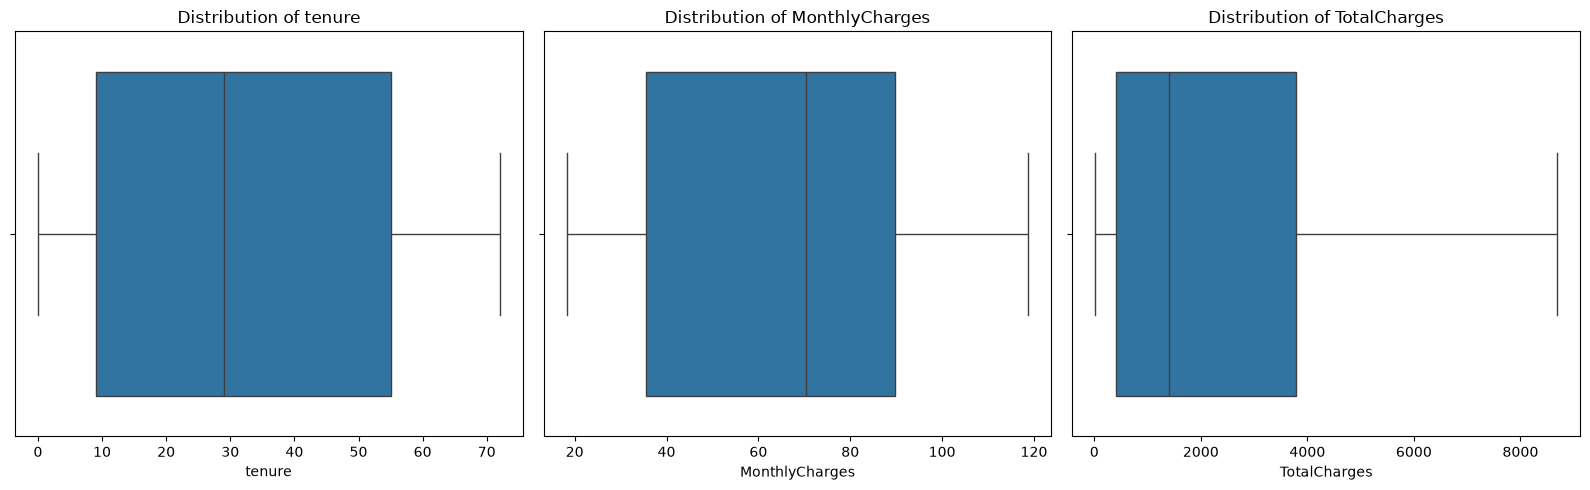

In [97]:
fig, axes= plt.subplots(1,3, figsize=(16,5))
for i, col in enumerate(num_cols):
    sns.boxplot(x= df[col], ax= axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()

# Outlier detection using IQR and Z-score method

In [98]:
outlier= {}
for col in num_cols:
    series= df[col]
    q1= series.quantile(0.25)
    q3= series.quantile(0.75)

    iqr= q3-q1

    lower_bound= q1 - 1.5*iqr
    upper_bound= q3 + 1.5*iqr

    iqr_outlier= series[(series<lower_bound)| (series>upper_bound)]

    z_score= np.abs(stats.zscore(series))
    Zscore_outlier= series[z_score>3]

    outlier[col]={
        'iqr_outlier_count':len(iqr_outlier),
        'Zscore_outlier_count': len(Zscore_outlier)
    }
outlier


{'tenure': {'iqr_outlier_count': 0, 'Zscore_outlier_count': 0},
 'MonthlyCharges': {'iqr_outlier_count': 0, 'Zscore_outlier_count': 0},
 'TotalCharges': {'iqr_outlier_count': 0, 'Zscore_outlier_count': 0}}

In [99]:
cat_features= [c for c in df.columns if df[c].dtype=='str' and c!= 'customerID']

for col in cat_features:
    print('\n\n----',col)
    print(df[col].value_counts())




---- gender
gender
Male      3555
Female    3488
Name: count, dtype: int64


---- Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64


---- Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64


---- PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64


---- MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


---- InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


---- OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


---- OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64


---- DeviceProtection
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count,

In [100]:
pd.crosstab(df['Contract'], df['Churn'], normalize= 'index')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


Churn,No,Yes
gender,,
Female,0.730791,0.269209
Male,0.738397,0.261603


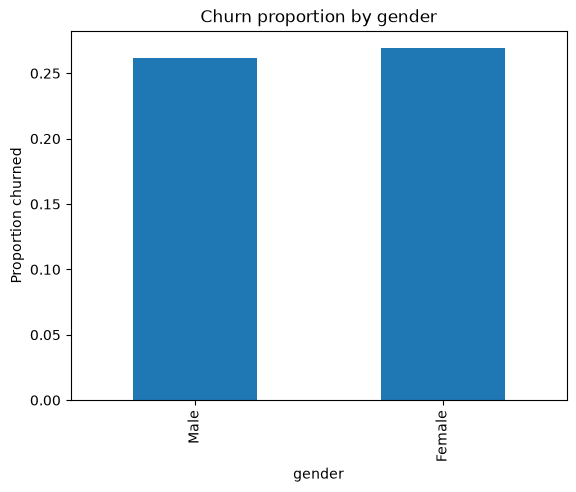

Churn,No,Yes
Partner,,
No,0.670420,0.329580
Yes,0.803351,0.196649


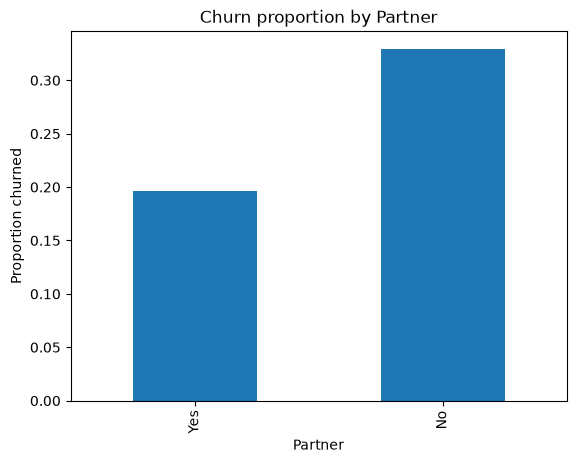

Churn,No,Yes
Dependents,,
No,0.687209,0.312791
Yes,0.845498,0.154502


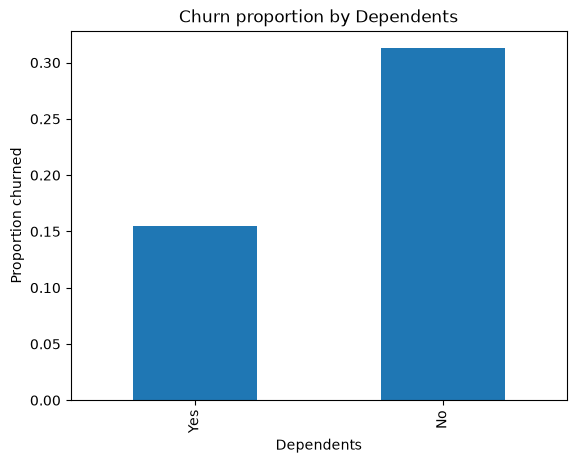

Churn,No,Yes
PhoneService,,
No,0.750733,0.249267
Yes,0.732904,0.267096


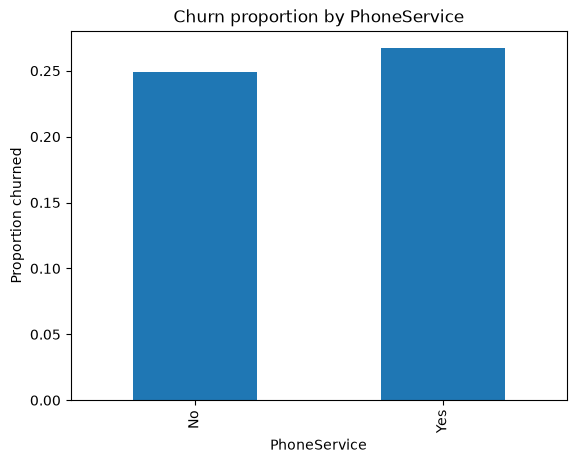

Churn,No,Yes
MultipleLines,,
No,0.749558,0.250442
No phone service,0.750733,0.249267
Yes,0.713901,0.286099


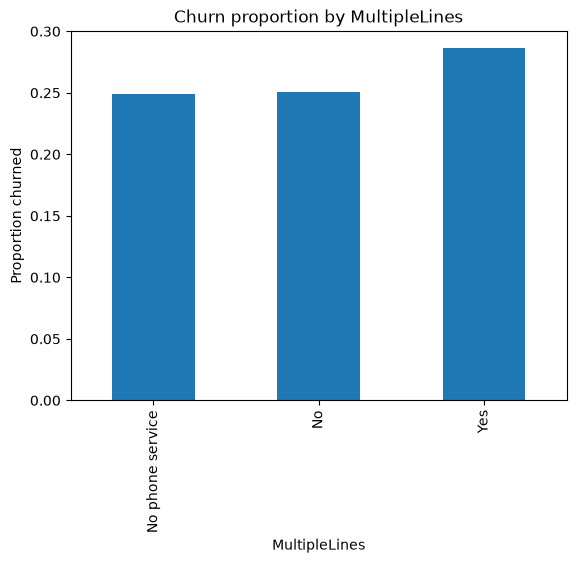

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


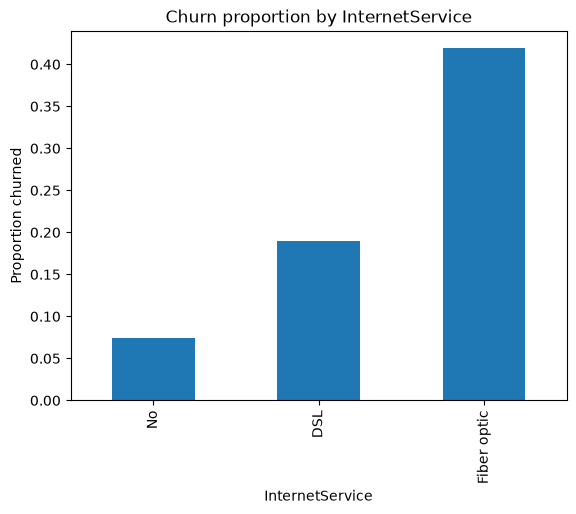

Churn,No,Yes
OnlineSecurity,,
No,0.582333,0.417667
No internet service,0.925950,0.074050
Yes,0.853888,0.146112


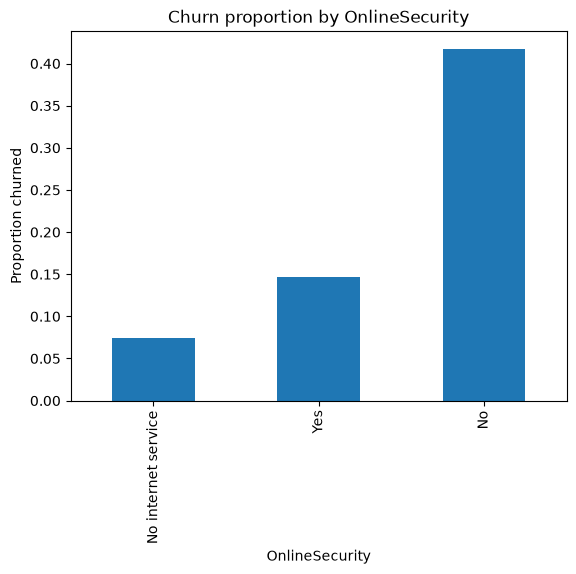

Churn,No,Yes
OnlineBackup,,
No,0.600712,0.399288
No internet service,0.925950,0.074050
Yes,0.784685,0.215315


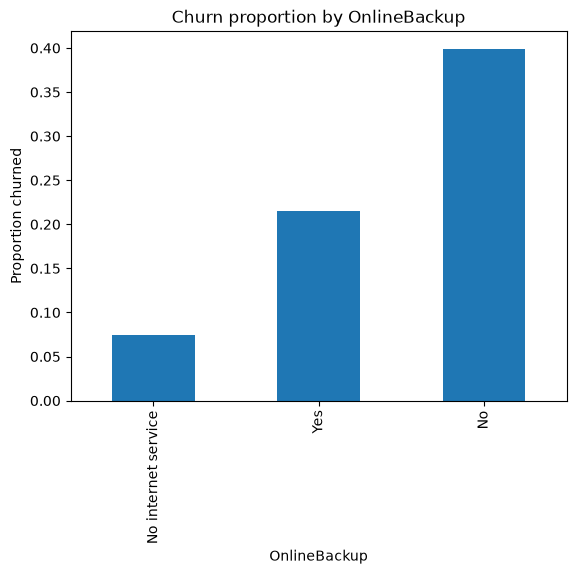

Churn,No,Yes
DeviceProtection,,
No,0.608724,0.391276
No internet service,0.925950,0.074050
Yes,0.774979,0.225021


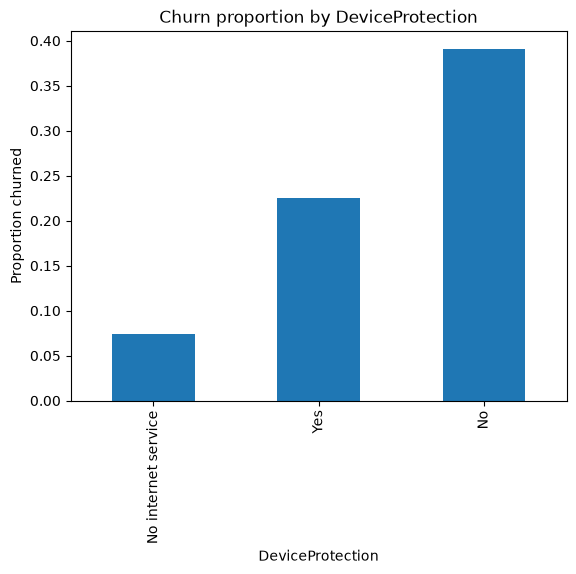

Churn,No,Yes
TechSupport,,
No,0.583645,0.416355
No internet service,0.925950,0.074050
Yes,0.848337,0.151663


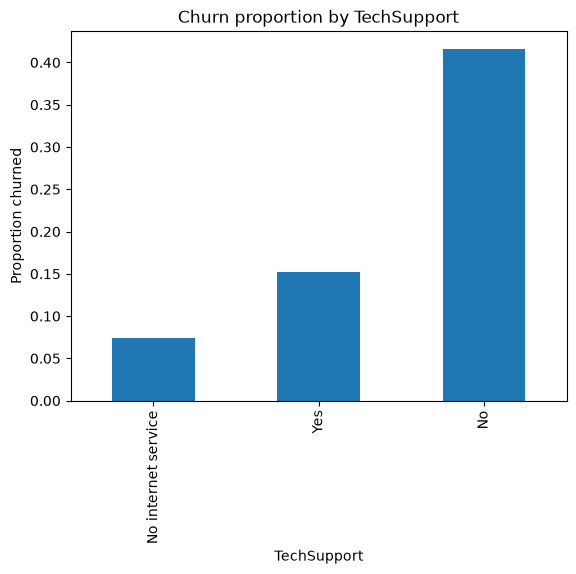

Churn,No,Yes
StreamingTV,,
No,0.664769,0.335231
No internet service,0.925950,0.074050
Yes,0.699298,0.300702


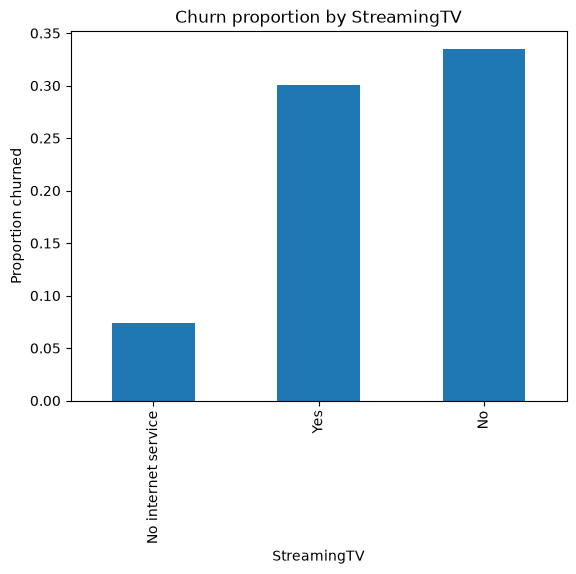

Churn,No,Yes
StreamingMovies,,
No,0.663196,0.336804
No internet service,0.925950,0.074050
Yes,0.700586,0.299414


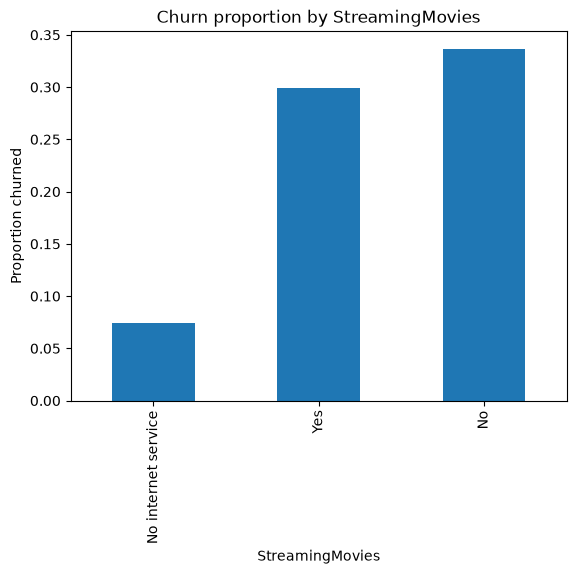

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


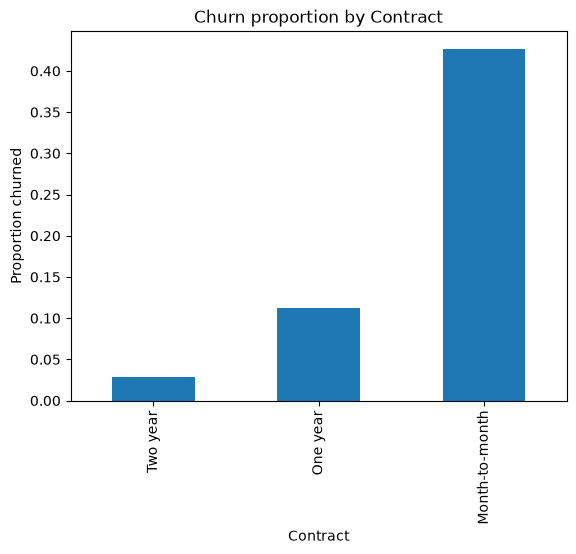

Churn,No,Yes
PaperlessBilling,,
No,0.836699,0.163301
Yes,0.664349,0.335651


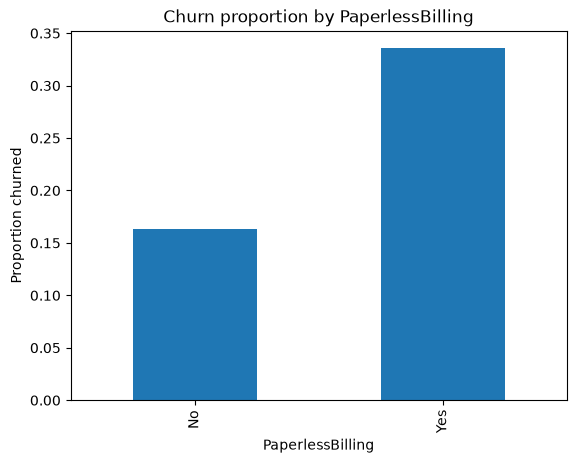

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


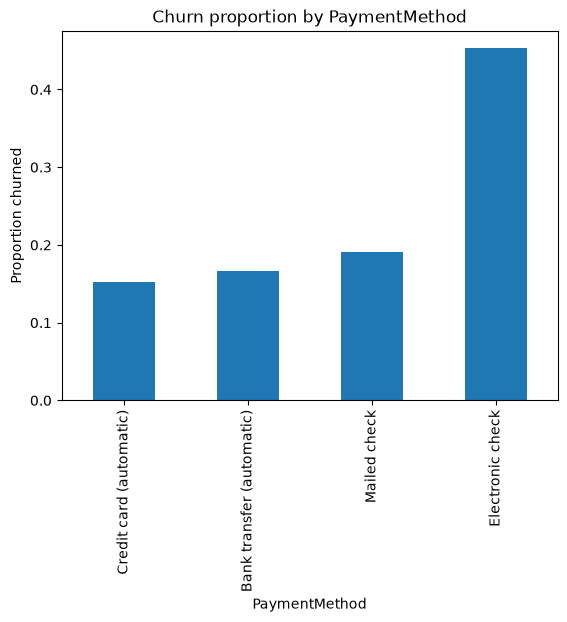

Churn,No,Yes
Churn,,
No,1.0,0.0
Yes,0.0,1.0


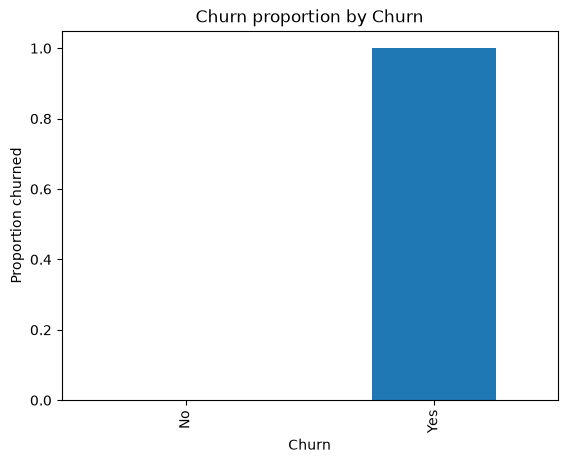

In [101]:
cat_features= [c for c in df.columns if df[c].dtype=='str' and c!= 'customerID']
for col in cat_features:
    churn_by_cat = pd.crosstab(df[col], df['Churn'], normalize='index')
    display(churn_by_cat)

# quick bar: churn 'Yes' proportion by category
    if 'Yes' in churn_by_cat.columns:
        churn_prop = churn_by_cat['Yes'].sort_values(ascending= True)
        churn_prop.plot(kind='bar')

        plt.title(f'Churn proportion by {col}')
        plt.ylabel('Proportion churned')
        plt.show()

# Bivariate Analysis


In [102]:
bins = [0, 12, 24, 48, 999]
labels = ["0-12", "13-24", "25-48", "48+"]
df["tenure_group"] = pd.cut(df["tenure"], bins=bins, labels=labels)

In [103]:
DEMOGRAPHIC = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
ACCOUNT = ['tenure', 'Contract', 'PaperlessBilling', 'PaymentMethod']
SERVICES = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
FINANCIAL = ['MonthlyCharges', 'TotalCharges']

In [104]:
df[SERVICES]

,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,No,No phone service,DSL,No,Yes,No,No,No,No
1,Yes,No,DSL,Yes,No,Yes,No,No,No
2,Yes,No,DSL,Yes,Yes,No,No,No,No
3,No,No phone service,DSL,Yes,No,Yes,Yes,No,No
4,Yes,No,Fiber optic,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...
7038,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes
7039,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes
7040,No,No phone service,DSL,Yes,No,No,No,No,No
7041,Yes,Yes,Fiber optic,No,No,No,No,No,No


In [105]:
#services count
service_flags = df[SERVICES].apply(lambda x: x.map({'Yes':1,'No':0,'No phone service':0,'No internet service':0}))
df['services_count'] = service_flags.sum(axis=1)


In [106]:
df.describe(include="object")

/var/folders/6g/8yh8tlw52pq_wd00c_6f4r4w0000gn/T/ipykernel_14902/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [146]:
def plot_cat_feature_dist(feature_name):
    (df.groupby(feature_name)['Churn'].value_counts(normalize=True)
    .unstack('Churn')
    .plot.bar(stacked=False))

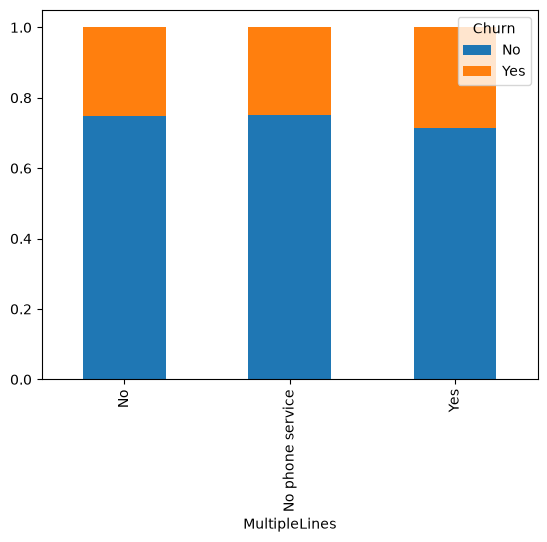

In [134]:
plot_cat_feature_dist('MultipleLines')

In [135]:
df['AvgMonthlyCharge'] = df['TotalCharges']/df['tenure']
df['DiffCharges'] = df['MonthlyCharges']-df['AvgMonthlyCharge']
df['DiffCharges'].describe()

count    7032.000000
mean       -0.001215
std         2.616165
min       -18.900000
25%        -1.160179
50%         0.000000
75%         1.147775
max        19.125000
Name: DiffCharges, dtype: float64

NameError: name 'div' is not defined

In [147]:
df['AvgMonthlyCharge'] = (df['TotalCharges'].div(df['tenure'])
.replace(np.nan,0))
df['DiffCharges'] = df['MonthlyCharges']-df['AvgMonthlyCharge']
df['DiffCharges'].describe()

count    7043.000000
mean        0.063475
std         3.211815
min       -18.900000
25%        -1.159091
50%         0.000000
75%         1.154880
max        80.850000
Name: DiffCharges, dtype: float64

In [148]:
df['diffBuckets']= pd.cut(df['tenure'], bins= 15)

In [155]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,services_count,AvgMonthlyCharge,DiffCharges,diffBuckets
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Yes,Electronic check,29.85,29.85,No,0-12,1.0,29.850000,0.000000,"(-0.072, 4.8]"
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,Mailed check,56.95,1889.50,No,25-48,3.0,55.573529,1.376471,"(33.6, 38.4]"
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Yes,Mailed check,53.85,108.15,Yes,0-12,3.0,54.075000,-0.225000,"(-0.072, 4.8]"
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,Bank transfer (automatic),42.30,1840.75,No,25-48,3.0,40.905556,1.394444,"(43.2, 48.0]"
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Yes,Electronic check,70.70,151.65,Yes,0-12,1.0,75.825000,-5.125000,"(-0.072, 4.8]"


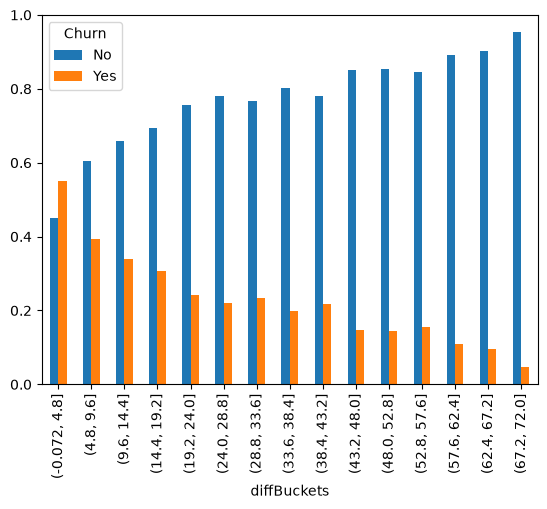

In [149]:
plot_cat_feature_dist('diffBuckets')

In [168]:
from sklearn.preprocessing import OneHotEncoder

numeric_columns = ['SeniorCitizen', 'tenure', 'MonthlyCharges']
categorical_columns = ['Partner', 'Dependents', 'MultipleLines',
'InternetService','OnlineSecurity',
'OnlineBackup','DeviceProtection',
'TechSupport','Contract','PaperlessBilling',
'PaymentMethod','diffBuckets']


ohe= OneHotEncoder(drop= "if_binary")

X_num= df[numeric_columns]
X_cat= df[categorical_columns]

X_cat_transform= ohe.fit_transform(X_cat)

In [189]:
ohe.inverse_transform(X_cat_transform.toarray())[0]

array(['Yes', 'No', 'No phone service', 'DSL', 'No', 'Yes', 'No', 'No',
       'Month-to-month', 'Yes', 'Electronic check',
       Interval(-0.072, 4.8, closed='right')], dtype=object)

Churn vs Servies. heatmap and churn rate for services 

* 'PhoneService',
* 'MultipleLines',
* 'InternetService',
* 'OnlineSecurity',
* 'OnlineBackup',
* 'DeviceProtection',
* 'TechSupport',
* 'StreamingTV',
* 'StreamingMovies'

In [218]:
service_churn= {}

for s in SERVICES:

    if df[s].eq("Yes").any():
        # Get the churn rate for customers who have this service ('Yes')
        service_user= df[df[s]== "Yes"]
        churn_rate = service_user[service_user['Churn'] == 'Yes'].shape[0] / service_user.shape[0]
        service_churn[s] = churn_rate
    else:
        # If service doesn't have 'Yes' values (different values like 'No internet service' or other)
        service_churn[s] = np.nan


print('\nApprox churn rate when service is Yes:')
print(pd.Series(service_churn).sort_values(ascending=False))   




Approx churn rate when service is Yes:
StreamingTV         0.300702
StreamingMovies     0.299414
MultipleLines       0.286099
PhoneService        0.267096
DeviceProtection    0.225021
OnlineBackup        0.215315
TechSupport         0.151663
OnlineSecurity      0.146112
InternetService          NaN
dtype: float64


Churn vs financial (t-tests)
* Compare MonthlyCharges between churners and non-churners

In [238]:
churn_yes= df[df['Churn']=="Yes"]['MonthlyCharges'].dropna()
churn_no= df[df['Churn']=="No"]['MonthlyCharges'].dropna()

print("MonthlyCharges --mean churners: {:.2f}, Non-Churners: {:.2f}".format(churn_yes.mean(), churn_no.mean()))

t_stat, p_val = stats.ttest_ind(churn_yes, churn_no, equal_var=False)
print('T-test for MonthlyCharges (Yes vs No): t={:.3f}, p={:.5f}'.format(t_stat, p_val))

# For TotalCharges
churn_yes_total= df[df['Churn']=="Yes"]['TotalCharges'].dropna()
churn_no_total= df[df['Churn']=="No"]['TotalCharges'].dropna()

if len(churn_yes_total) > 0 and len(churn_no_total) > 0:
    t_stat2, p_val2 = stats.ttest_ind(churn_yes_total, churn_no_total, equal_var=False)
    print('T-test for TotalCharges: t={:.3f}, p={:.5f}'.format(t_stat2, p_val2))



MonthlyCharges --mean churners: 74.44, Non-Churners: 61.27
T-test for MonthlyCharges (Yes vs No): t=18.408, p=0.00000
T-test for TotalCharges: t=-18.801, p=0.00000


* MonthlyCharges (Mean 74.44 vs 61.27): Customers who churned paid significantly higher monthly bills on average than those who stayed. The massive positive t-statistic ($18.408$) and a p-value of essentially $0.0$ ($p < 0.001$) prove this difference is extremely robust and not random noise. This points directly to price sensitivity as a major driver for customer churn.
* TotalCharges (Negative t-statistic of -18.801, $p = 0.00000$): Even though churners pay more per month, they accumulate lower total charges overall. This happens because churners tend to leave early in their lifecycle (low tenure), meaning they don't stick around long enough to rack up high cumulative payments. The negative sign on the t-statistic reflects this inverse relationship relative to the groups.

Chi-Square test for categorical feature and Churn.


In [246]:
from scipy.stats import chi2, chi2_contingency
for col in ['Contract','PaymentMethod','InternetService','SeniorCitizen']:
    ct= pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, ex = chi2_contingency(ct)

    print('\nChi-square for', col, ': p-value =', p)


Chi-square for Contract : p-value = 5.863038300673393e-258

Chi-square for PaymentMethod : p-value = 3.6823546520098007e-140

Chi-square for InternetService : p-value = 9.571788222840544e-160

Chi-square for SeniorCitizen : p-value = 1.5100668050923772e-36


# Business Insights Generation
* Identify high-risk profiles
* Retention opportunities and revenue impact

High risk profiles based on the simple ranking by difference in proportion.

tenure_group
0-12     0.476782
13-24    0.287109
25-48    0.203890
48+      0.095132
Name: Yes, dtype: float64

In [258]:
high_risk= ['Contract', 'InternetService', 'PaymentMethod', 'tenure_group']
risk_summary=[]

for col in high_risk:
    prop= df.groupby(col)['Churn'].value_counts(normalize=True).unstack().fillna(0)

    if "Yes" in prop.columns:
        prop= prop['Yes']
        top = prop.sort_values(ascending=False).head(3)

        for idx, val in top.items():
            risk_summary.append((col, idx, val))

risk_df = pd.DataFrame(risk_summary, columns=['feature','category','churn_rate'])
print('Top high-risk categories:')
print(risk_df)



Top high-risk categories:
            feature                   category  churn_rate
0          Contract             Month-to-month    0.427097
1          Contract                   One year    0.112695
2          Contract                   Two year    0.028319
3   InternetService                Fiber optic    0.418928
4   InternetService                        DSL    0.189591
5   InternetService                         No    0.074050
6     PaymentMethod           Electronic check    0.452854
7     PaymentMethod               Mailed check    0.191067
8     PaymentMethod  Bank transfer (automatic)    0.167098
9      tenure_group                       0-12    0.476782
10     tenure_group                      13-24    0.287109
11     tenure_group                      25-48    0.203890


In [272]:
avg_monthly_charges= df['MonthlyCharges'].mean()
churners= df[df["Churn"]=="Yes"]
avg_monthly_loss= churners['MonthlyCharges'].mean()
annual_revenue_lost= avg_monthly_loss *12

print('Number of churners:', len(churners))
print('Estimated monthly revenue lost (current churners): ${:,.2f}'.format(avg_monthly_loss))
print('Estimated annualized revenue lost: ${:,.2f}'.format(annual_revenue_lost))

m2m = df[df['Contract']=='Month-to-month']
m2m_churn_rate = (m2m['Churn']=='Yes').mean()
m2m_monthly_revenue = m2m['MonthlyCharges'].sum()
print('\nMonth-to-month subset size:', len(m2m), 'churn rate:', m2m_churn_rate)
print('Revenue from Month-to-month customers (monthly): ${:,.2f}'.format(m2m_monthly_revenue))
print('Estimated monthly revenue at risk (if churn rate persists): ${:,.2f}'.format(m2m_monthly_revenue * m2m_churn_rate))

Number of churners: 1869
Estimated monthly revenue lost (current churners): $74.44
Estimated annualized revenue lost: $893.30

Month-to-month subset size: 3875 churn rate: 0.4270967741935484
Revenue from Month-to-month customers (monthly): $257,294.15
Estimated monthly revenue at risk (if churn rate persists): $109,889.50


In [276]:
cleaned_path = '/Users/Admin/Me only/Customer churn/src/data/telco-customer-churn_cleaned.csv'
df.to_csv(cleaned_path, index=False)

print('Saved cleaned dataframe to', cleaned_path)

Saved cleaned dataframe to /Users/Admin/Me only/Customer churn/src/data/telco-customer-churn_cleaned.csv
